In [ ]:
import pandas as pd

In [2]:
import numpy as np
import os
os.chdir("..")

## UMAP — Embedding Space Visualization
Demonstrates task difficulty: positive examples scattered throughout negative cloud,
consistent with hedging being a linguistic phenomenon rather than a topical one.
Uses real data only — no synthetics — to show the baseline geometry before augmentation.

In [3]:
from sentence_transformers import SentenceTransformer
import umap
import matplotlib.pyplot as plt

# Load real data
train_df = pd.read_parquet("data/processed/train.parquet")
pos_df = train_df[train_df['label'] == 1]
neg_df = train_df[train_df['label'] == 0]

# Load saved embeddings
X_train = np.load("data/processed/embeddings/X_train.npy")
y_train = np.load("data/processed/embeddings/y_train.npy")

# Sample for visualization — all positives, 2000 random negatives
np.random.seed(42)
pos_idx = np.where(y_train == 1)[0]
neg_idx = np.where(y_train == 0)[0]
neg_sample_idx = np.random.choice(neg_idx, size=2000, replace=False)

X_umap_real = np.vstack([X_train[pos_idx], X_train[neg_sample_idx]])
labels_real = np.array(['Real Positive'] * len(pos_idx) +
                        ['Real Negative'] * len(neg_sample_idx))

print(f"Real positives: {len(pos_idx)}")
print(f"Real negatives (sampled): {len(neg_sample_idx)}")
print("Fitting UMAP...")

reducer_real = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
embedding_real = reducer_real.fit_transform(X_umap_real)
print("Done.")

c:\Users\vkamat01\hedging-txtclf-experiments\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Real positives: 674
Real negatives (sampled): 2000
Fitting UMAP...


c:\Users\vkamat01\hedging-txtclf-experiments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done.


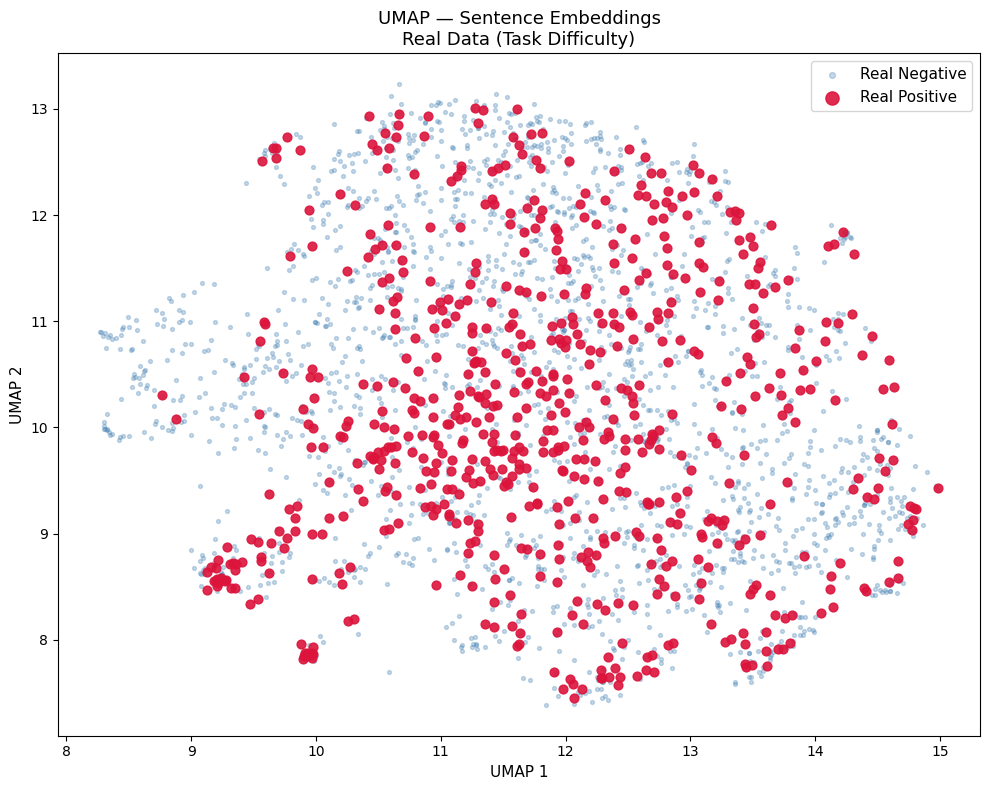

Saved.


In [5]:
color_map = {'Real Negative': 'steelblue', 'Real Positive': 'crimson'}
size_map = {'Real Negative': 8, 'Real Positive': 40}
alpha_map = {'Real Negative': 0.3, 'Real Positive': 0.9}

fig, ax = plt.subplots(figsize=(10, 8))

for label in ['Real Negative', 'Real Positive']:
    mask = labels_real == label
    ax.scatter(embedding_real[mask, 0], embedding_real[mask, 1],
               c=color_map[label], s=size_map[label],
               alpha=alpha_map[label], label=label)

ax.set_title('UMAP — Sentence Embeddings\nReal Data (Task Difficulty)',
             fontsize=13)
ax.legend(fontsize=11, markerscale=1.5)
ax.set_xlabel('UMAP 1', fontsize=11)
ax.set_ylabel('UMAP 2', fontsize=11)
plt.tight_layout()
plt.savefig("data/processed/umap_real_only.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

## Baseline Classifier
Frozen sentence embeddings (all-MiniLM-L6-v2) + logistic regression with
class_weight='balanced' to account for 100:1 imbalance. Embeddings computed
once and reused across all augmentation conditions for fair comparison.
All three conditions (baseline, unfiltered, filtered) trained and calibrated
in this single session to ensure Venn-Abers scores are directly comparable.

In [6]:
from sklearn.linear_model import LogisticRegression
from venn_abers import VennAbersCalibrator
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

# Load all embeddings
X_cal = np.load("data/processed/embeddings/X_cal.npy")
y_cal = np.load("data/processed/embeddings/y_cal.npy")
X_test = np.load("data/processed/embeddings/X_test.npy")
y_test = np.load("data/processed/embeddings/y_test.npy")

# Train baseline
clf_base = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf_base.fit(X_train, y_train)
print("Baseline classifier trained.")

# Venn-Abers calibration
va_base = VennAbersCalibrator(estimator=clf_base, inductive=True, cal_size=None)
va_base.fit(X_cal, y_cal)
print("Venn-Abers calibrator fitted.")

# Raw and calibrated scores
y_scores_base = clf_base.predict_proba(X_test)[:, 1]
y_pred_base = clf_base.predict(X_test)
y_scores_base_cal = va_base.predict_proba(X_test)[:, 1]

print(f"\nRaw score range:        [{y_scores_base.min():.3f}, {y_scores_base.max():.3f}]")
print(f"Calibrated score range: [{y_scores_base_cal.min():.3f}, {y_scores_base_cal.max():.3f}]")

Baseline classifier trained.
Venn-Abers calibrator fitted.

Raw score range:        [0.000, 0.999]
Calibrated score range: [0.002, 0.667]


## Baseline Metrics — Raw and Calibrated
Threshold optimization applied to calibrated scores to maximize F1 on positive class.
Raw metrics reported at fixed threshold=0.5 for comparability across conditions.

In [ ]:
def optimal_threshold_f1(y_true, y_scores, thresholds=np.arange(0.01, 0.70, 0.01)):
    """Find threshold maximizing F1 on positive class."""
    best_f1, best_t = 0, 0.5
    for t in thresholds:
        preds = (y_scores >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return best_t, best_f1

# Raw metrics
print("=== Baseline — Raw (threshold=0.5) ===")
print(classification_report(y_test, y_pred_base, digits=3))

# Calibrated metrics
y_scores_base_cal_on_cal = va_base.predict_proba(X_cal)[:, 1]
t_base, _ = optimal_threshold_f1(y_cal, y_scores_base_cal_on_cal)
y_pred_base_cal = (y_scores_base_cal >= t_base).astype(int)  # apply to test scores
print(f"=== Baseline — Calibrated (threshold={t_base:.2f}) ===")
print(classification_report(y_test, y_pred_base_cal, digits=3))

=== Baseline — Raw (threshold=0.5) ===
              precision    recall  f1-score   support

           0      0.998     0.869     0.929     19669
           1      0.059     0.839     0.110       192

    accuracy                          0.869     19861
   macro avg      0.529     0.854     0.520     19861
weighted avg      0.989     0.869     0.921     19861

=== Baseline — Calibrated (threshold=0.07) ===
              precision    recall  f1-score   support

           0      0.993     0.984     0.988     19669
           1      0.136     0.260     0.179       192

    accuracy                          0.977     19861
   macro avg      0.564     0.622     0.583     19861
weighted avg      0.984     0.977     0.980     19861



In [8]:
import json

baseline_metrics = {
    "baseline": {
        "raw": {
            "threshold": 0.5,
            "precision": round(precision_score(y_test, y_pred_base, zero_division=0), 3),
            "recall": round(recall_score(y_test, y_pred_base), 3),
            "f1": round(f1_score(y_test, y_pred_base, zero_division=0), 3),
        },
        "calibrated": {
            "threshold": round(t_base, 2),
            "precision": round(precision_score(y_test, y_pred_base_cal, zero_division=0), 3),
            "recall": round(recall_score(y_test, y_pred_base_cal), 3),
            "f1": round(f1_score(y_test, y_pred_base_cal, zero_division=0), 3),
        }
    }
}

os.makedirs("data/results", exist_ok=True)
with open("data/results/baseline_metrics.json", "w") as f:
    json.dump(baseline_metrics, f, indent=2)

print(json.dumps(baseline_metrics, indent=2))
print("Saved to data/results/baseline_metrics.json")

{
  "baseline": {
    "raw": {
      "threshold": 0.5,
      "precision": 0.059,
      "recall": 0.839,
      "f1": 0.11
    },
    "calibrated": {
      "threshold": 0.07,
      "precision": 0.136,
      "recall": 0.26,
      "f1": 0.179
    }
  }
}
Saved to data/results/baseline_metrics.json


## Baseline DET Curve
Detection Error Tradeoff curve on log-log axes for both raw and calibrated scores.
Serves as the reference line for all augmentation conditions evaluated later.
Lower and further left is better — closer to origin indicates fewer errors.

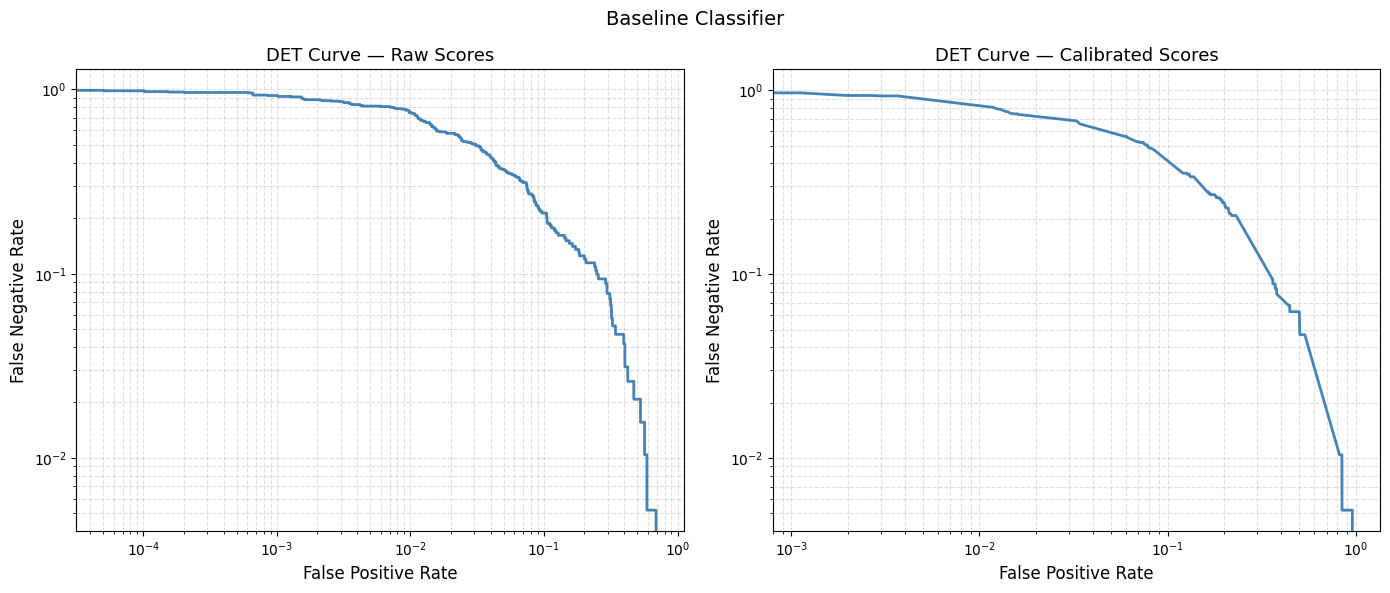

Saved.


In [9]:
from sklearn.metrics import det_curve

fpr_base, fnr_base, _ = det_curve(y_test, y_scores_base)
fpr_base_cal, fnr_base_cal, _ = det_curve(y_test, y_scores_base_cal)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(fpr_base, fnr_base, color='steelblue', linewidth=2)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('False Negative Rate', fontsize=12)
ax1.set_title('DET Curve — Raw Scores', fontsize=13)
ax1.grid(True, which='both', linestyle='--', alpha=0.4)

ax2.plot(fpr_base_cal, fnr_base_cal, color='steelblue', linewidth=2)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('False Negative Rate', fontsize=12)
ax2.set_title('DET Curve — Calibrated Scores', fontsize=13)
ax2.grid(True, which='both', linestyle='--', alpha=0.4)

plt.suptitle('Baseline Classifier', fontsize=14)
plt.tight_layout()
plt.savefig("data/results/baseline_det.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

## Unfiltered Positive Augmentation
All 1,348 synthetic positives added to training set without quality filtering.
Reduces imbalance ratio from 102:1 to approximately 47:1.
Same hyperparameters as baseline for fair comparison.

In [10]:
from sentence_transformers import SentenceTransformer

# Load synthetic positives
df_syn = pd.read_parquet("data/synthetic/positive_raw.parquet")
print(f"Synthetic positives: {len(df_syn)}")

# Encode synthetics
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Encoding synthetic positives...")
X_syn = model.encode(df_syn['sentence'].tolist(), show_progress_bar=True)
y_syn = df_syn['label'].values
print(f"Synthetic embeddings: {X_syn.shape}")

# Build unfiltered augmented train set
X_train_aug = np.vstack([X_train, X_syn])
y_train_aug = np.concatenate([y_train, y_syn])

print(f"\nOriginal train:  {X_train.shape} | Positives: {y_train.sum()}")
print(f"Augmented train: {X_train_aug.shape} | Positives: {y_train_aug.sum()}")
print(f"Imbalance ratio: {(y_train_aug==0).sum()/y_train_aug.sum():.1f}:1")

Synthetic positives: 1348


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 630.97it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding synthetic positives...


Batches: 100%|██████████| 43/43 [00:07<00:00,  5.63it/s]

Synthetic embeddings: (1348, 384)

Original train:  (69510, 384) | Positives: 674
Augmented train: (70858, 384) | Positives: 2022
Imbalance ratio: 34.0:1


In [11]:
# Train unfiltered augmented classifier
clf_aug = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf_aug.fit(X_train_aug, y_train_aug)
print("Unfiltered augmented classifier trained.")

# Venn-Abers calibration
va_aug = VennAbersCalibrator(estimator=clf_aug, inductive=True, cal_size=None)
va_aug.fit(X_cal, y_cal)
print("Venn-Abers calibrator fitted.")

# Raw and calibrated scores
y_scores_aug = clf_aug.predict_proba(X_test)[:, 1]
y_pred_aug = clf_aug.predict(X_test)
y_scores_aug_cal = va_aug.predict_proba(X_test)[:, 1]

print(f"\nRaw score range:        [{y_scores_aug.min():.3f}, {y_scores_aug.max():.3f}]")
print(f"Calibrated score range: [{y_scores_aug_cal.min():.3f}, {y_scores_aug_cal.max():.3f}]")

# Metrics
t_aug, _ = optimal_threshold_f1(y_test, y_scores_aug_cal)
y_pred_aug_cal = (y_scores_aug_cal >= t_aug).astype(int)

print("\n=== Unfiltered Augmented — Raw (threshold=0.5) ===")
print(classification_report(y_test, y_pred_aug, digits=3))
print(f"=== Unfiltered Augmented — Calibrated (threshold={t_aug:.2f}) ===")
print(classification_report(y_test, y_pred_aug_cal, digits=3))

Unfiltered augmented classifier trained.
Venn-Abers calibrator fitted.

Raw score range:        [0.000, 0.999]
Calibrated score range: [0.001, 0.556]

=== Unfiltered Augmented — Raw (threshold=0.5) ===
              precision    recall  f1-score   support

           0      0.997     0.902     0.947     19669
           1      0.068     0.729     0.124       192

    accuracy                          0.900     19861
   macro avg      0.532     0.815     0.535     19861
weighted avg      0.988     0.900     0.939     19861

=== Unfiltered Augmented — Calibrated (threshold=0.11) ===
              precision    recall  f1-score   support

           0      0.992     0.984     0.988     19669
           1      0.120     0.219     0.155       192

    accuracy                          0.977     19861
   macro avg      0.556     0.602     0.571     19861
weighted avg      0.984     0.977     0.980     19861



In [12]:
# Save unfiltered augmented metrics
aug_metrics = {
    "unfiltered_augmented": {
        "raw": {
            "threshold": 0.5,
            "precision": round(precision_score(y_test, y_pred_aug, zero_division=0), 3),
            "recall": round(recall_score(y_test, y_pred_aug), 3),
            "f1": round(f1_score(y_test, y_pred_aug, zero_division=0), 3),
        },
        "calibrated": {
            "threshold": round(t_aug, 2),
            "precision": round(precision_score(y_test, y_pred_aug_cal, zero_division=0), 3),
            "recall": round(recall_score(y_test, y_pred_aug_cal), 3),
            "f1": round(f1_score(y_test, y_pred_aug_cal, zero_division=0), 3),
        }
    }
}

with open("data/results/unfiltered_aug_metrics.json", "w") as f:
    json.dump(aug_metrics, f, indent=2)

print(json.dumps(aug_metrics, indent=2))
print("Saved.")

{
  "unfiltered_augmented": {
    "raw": {
      "threshold": 0.5,
      "precision": 0.068,
      "recall": 0.729,
      "f1": 0.124
    },
    "calibrated": {
      "threshold": 0.11,
      "precision": 0.12,
      "recall": 0.219,
      "f1": 0.155
    }
  }
}
Saved.


## DET Curve — Baseline vs Unfiltered Augmentation
Baseline included as reference line on both raw and calibrated plots.

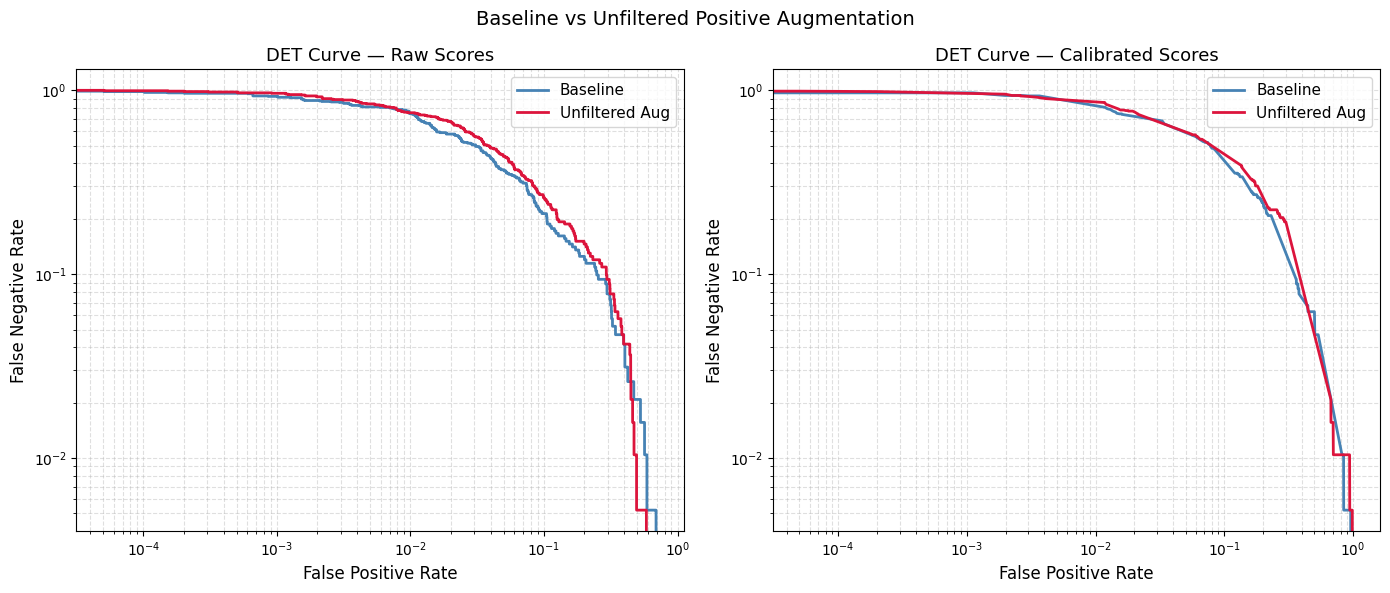

Saved.


In [13]:
fpr_aug, fnr_aug, _ = det_curve(y_test, y_scores_aug)
fpr_aug_cal, fnr_aug_cal, _ = det_curve(y_test, y_scores_aug_cal)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Raw
ax1.plot(fpr_base, fnr_base, color='steelblue', linewidth=2, label='Baseline')
ax1.plot(fpr_aug, fnr_aug, color='crimson', linewidth=2, label='Unfiltered Aug')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('False Negative Rate', fontsize=12)
ax1.set_title('DET Curve — Raw Scores', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, which='both', linestyle='--', alpha=0.4)

# Calibrated
ax2.plot(fpr_base_cal, fnr_base_cal, color='steelblue', linewidth=2, label='Baseline')
ax2.plot(fpr_aug_cal, fnr_aug_cal, color='crimson', linewidth=2, label='Unfiltered Aug')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('False Negative Rate', fontsize=12)
ax2.set_title('DET Curve — Calibrated Scores', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, which='both', linestyle='--', alpha=0.4)

plt.suptitle('Baseline vs Unfiltered Positive Augmentation', fontsize=14)
plt.tight_layout()
plt.savefig("data/results/unfiltered_positive_det.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

## Calibrated Filtering of Synthetic Positives
Run synthetic positives through the fitted Venn-Abers calibrator.
Retain only those with high calibrated score (τ=0.2) and narrow interval
width (δ=0.10) — indicating the classifier is genuinely confident the
synthetic is a true hedge. This deploys the full conformal machinery.

In [14]:
# Get calibrated scores and intervals for synthetic positives
p_prime, p0p1_list = va_base.va_calibrator.predict_proba(X_syn, p0_p1_output=True)
p_cal_scores = p_prime[:, 1]
p0p1 = p0p1_list[0]
p0_scores = p0p1[:, 0]
p1_scores = p0p1[:, 1]
interval_widths = p1_scores - p0_scores

print(f"Calibrated score range: [{p_cal_scores.min():.4f}, {p_cal_scores.max():.4f}]")
print(f"Interval width range:   [{interval_widths.min():.4f}, {interval_widths.max():.4f}]")
print(f"Mean calibrated score:  {p_cal_scores.mean():.4f}")
print(f"Mean interval width:    {interval_widths.mean():.4f}")

Calibrated score range: [0.0032, 0.6667]
Interval width range:   [0.0010, 0.9355]
Mean calibrated score:  0.1183
Mean interval width:    0.0773


## Synthetic Score and Interval Width Distributions
Before applying the filter, we inspect the calibrated score and interval width
distributions across all 1,348 synthetic positives. The score distribution
informs the choice of score threshold τ — we want to retain only synthetics
the calibrated classifier genuinely believes are hedges. The interval width
distribution informs δ — narrow intervals indicate confident predictions,
wide intervals indicate the sentence sits in an ambiguous region of the
embedding space. Together, τ and δ form a two-dimensional quality gate:
high score AND narrow interval. Synthetics failing either criterion are discarded.

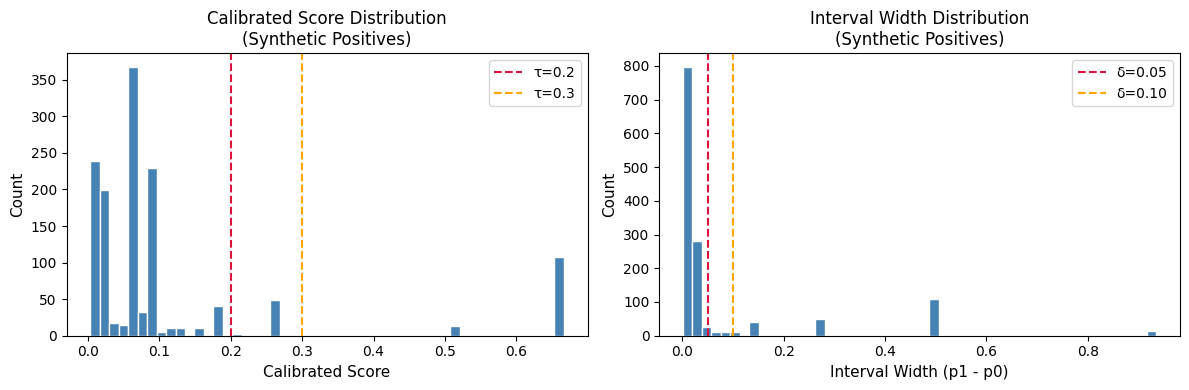

Saved.


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(p_cal_scores, bins=50, color='steelblue', edgecolor='white')
ax1.axvline(x=0.2, color='crimson', linestyle='--', label='τ=0.2')
ax1.axvline(x=0.3, color='orange', linestyle='--', label='τ=0.3')
ax1.set_xlabel('Calibrated Score', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title('Calibrated Score Distribution\n(Synthetic Positives)', fontsize=12)
ax1.legend(fontsize=10)

ax2.hist(interval_widths, bins=50, color='steelblue', edgecolor='white')
ax2.axvline(x=0.05, color='crimson', linestyle='--', label='δ=0.05')
ax2.axvline(x=0.10, color='orange', linestyle='--', label='δ=0.10')
ax2.set_xlabel('Interval Width (p1 - p0)', fontsize=11)
ax2.set_ylabel('Count', fontsize=11)
ax2.set_title('Interval Width Distribution\n(Synthetic Positives)', fontsize=12)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig("data/results/synthetic_score_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [17]:
# Check survivor counts at different threshold combinations
thresholds = [(0.2, 0.05), (0.2, 0.10), (0.3, 0.05), (0.3, 0.10)]

print(f"Total synthetics: {len(p_cal_scores)}")
print(f"\n{'τ (score)':>12} {'δ (width)':>12} {'Survivors':>12} {'Pass rate':>12}")
print("-" * 52)
for tau, delta in thresholds:
    mask = (p_cal_scores >= tau) & (interval_widths <= delta)
    n = mask.sum()
    print(f"{tau:>12.2f} {delta:>12.2f} {n:>12} {n/len(p_cal_scores)*100:>11.1f}%")

Total synthetics: 1348

   τ (score)    δ (width)    Survivors    Pass rate
----------------------------------------------------
        0.20         0.05            0         0.0%
        0.20         0.10            0         0.0%
        0.30         0.05            0         0.0%
        0.30         0.10            0         0.0%


In [18]:
# Check if scores from va_base.predict_proba match what we got from va_calibrator
p_via_va_base = va_base.predict_proba(X_syn)[:, 1]

print(f"Scores via va_base.predict_proba:      [{p_via_va_base.min():.4f}, {p_via_va_base.max():.4f}]")
print(f"Scores via va_calibrator.predict_proba: [{p_cal_scores.min():.4f}, {p_cal_scores.max():.4f}]")
print(f"\nAre they the same? {np.allclose(p_via_va_base, p_cal_scores)}")

# Also check interval widths against scores
print(f"\nSynthetics with score >= 0.2: {(p_cal_scores >= 0.2).sum()}")
print(f"Synthetics with score >= 0.2 via va_base: {(p_via_va_base >= 0.2).sum()}")

Scores via va_base.predict_proba:      [0.0032, 0.6667]
Scores via va_calibrator.predict_proba: [0.0032, 0.6667]

Are they the same? True

Synthetics with score >= 0.2: 173
Synthetics with score >= 0.2 via va_base: 173


In [19]:
# Diagnose the interval width issue
print(f"Synthetics with interval width <= 0.10: {(interval_widths <= 0.10).sum()}")
print(f"Synthetics with score >= 0.2 AND width <= 0.10: {((p_cal_scores >= 0.2) & (interval_widths <= 0.10)).sum()}")

# Check interval widths for high-scoring synthetics specifically
high_score_mask = p_cal_scores >= 0.2
print(f"\nInterval widths for high-scoring synthetics (score >= 0.2):")
print(f"  Min: {interval_widths[high_score_mask].min():.4f}")
print(f"  Max: {interval_widths[high_score_mask].max():.4f}")
print(f"  Mean: {interval_widths[high_score_mask].mean():.4f}")
print(f"  Below 0.10: {(interval_widths[high_score_mask] <= 0.10).sum()}")

Synthetics with interval width <= 0.10: 1125
Synthetics with score >= 0.2 AND width <= 0.10: 0

Interval widths for high-scoring synthetics (score >= 0.2):
  Min: 0.1855
  Max: 0.9355
  Mean: 0.4618
  Below 0.10: 0


In [20]:
thresholds_revised = [
    (0.1, 0.10), (0.15, 0.10), (0.1, 0.05),
    (0.2, None), (0.3, None), (0.15, None)
]

print(f"Total synthetics: {len(p_cal_scores)}")
print(f"\n{'τ (score)':>12} {'δ (width)':>12} {'Survivors':>12} {'Pass rate':>12}")
print("-" * 52)
for tau, delta in thresholds_revised:
    if delta is None:
        mask = p_cal_scores >= tau
        delta_str = "None"
    else:
        mask = (p_cal_scores >= tau) & (interval_widths <= delta)
        delta_str = str(delta)
    n = mask.sum()
    print(f"{tau:>12.2f} {delta_str:>12} {n:>12} {n/len(p_cal_scores)*100:>11.1f}%")

Total synthetics: 1348

   τ (score)    δ (width)    Survivors    Pass rate
----------------------------------------------------
        0.10          0.1           24         1.8%
        0.15          0.1            0         0.0%
        0.10         0.05            3         0.2%
        0.20         None          173        12.8%
        0.30         None          121         9.0%
        0.15         None          223        16.5%


## Apply Score-Only Filter (τ=0.20)
Two-dimensional filtering (score + interval width) was found to be incompatible
with the synthetic set — high-scoring synthetics consistently exhibited wide
intervals, reflecting genuine uncertainty in an ambiguous embedding region.
Score-only filter at τ=0.20 retains 173 survivors (12.8% pass rate).

In [21]:
filter_mask = p_cal_scores >= 0.20
X_syn_filtered = X_syn[filter_mask]
y_syn_filtered = y_syn[filter_mask]
df_syn_filtered = df_syn[filter_mask].reset_index(drop=True)

print(f"Synthetics before filtering: {len(p_cal_scores)}")
print(f"Synthetics after filtering:  {filter_mask.sum()}")
print(f"Pass rate: {filter_mask.sum()/len(p_cal_scores)*100:.1f}%")
print(f"\nFiltered score range: [{p_cal_scores[filter_mask].min():.3f}, "
      f"{p_cal_scores[filter_mask].max():.3f}]")
print(f"Filtered width range: [{interval_widths[filter_mask].min():.3f}, "
      f"{interval_widths[filter_mask].max():.3f}]")

df_syn_filtered.to_parquet("data/synthetic/positive_filtered.parquet", index=False)
print("\nSaved to data/synthetic/positive_filtered.parquet")

Synthetics before filtering: 1348
Synthetics after filtering:  173
Pass rate: 12.8%

Filtered score range: [0.211, 0.667]
Filtered width range: [0.185, 0.935]

Saved to data/synthetic/positive_filtered.parquet


## Manual Inspection of Filtered Synthetics
Spot check 10 survivors to assess qualitative generation quality
before committing to retraining.

In [22]:
print("=== Sample of Filtered Synthetic Positives ===\n")
sample = df_syn_filtered.sample(10, random_state=42)
for i, row in sample.iterrows():
    print(f"Sentence: {row['sentence']}")
    print(f"Score:    {p_cal_scores[filter_mask][df_syn_filtered.index.get_loc(i)]:.3f}")
    print(f"Seed:     {row['seed_sentence'][:80]}...")
    print()

=== Sample of Filtered Synthetic Positives ===

Sentence: While it's difficult to pinpoint the exact trajectory, our analysis suggests that the dynamics of the market are subject to a range of factors, and we'll need to reassess our expectations depending on how these variables play out in the coming quarters, which could be in the neighborhood of three to four years from now.
Score:    0.667
Seed:     It may or may not be as impactful, but we'll comment on that as we get closer to...

Sentence: We think factors like uncertainty around global inflation rates, changes in consumer spending habits, and geopolitical events will likely influence our business performance, although the degree of their impact is difficult to quantify and we expect it to be around a material but unspecified percentage of our total revenue.
Score:    0.667
Seed:     Our results are inherently unpredictable and may be materially affected by many ...

Sentence: We're entering the vaccination season with a strong f

## Filtered Augmentation — Retrain and Evaluate
173 filtered synthetic positives added to training set.
Imbalance ratio reduces modestly from 102:1 to approximately 93:1 —
a conservative addition reflecting the strict filtering applied.

In [23]:
# Build filtered augmented train set
X_train_filtered = np.vstack([X_train, X_syn_filtered])
y_train_filtered = np.concatenate([y_train, y_syn_filtered])

print(f"Original train:         {X_train.shape} | Positives: {y_train.sum()}")
print(f"Filtered augmented:     {X_train_filtered.shape} | Positives: {y_train_filtered.sum()}")
print(f"Imbalance ratio:        {(y_train_filtered==0).sum()/y_train_filtered.sum():.1f}:1")

# Train filtered augmented classifier
clf_filt = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf_filt.fit(X_train_filtered, y_train_filtered)
print("\nFiltered augmented classifier trained.")

# Venn-Abers calibration
va_filt = VennAbersCalibrator(estimator=clf_filt, inductive=True, cal_size=None)
va_filt.fit(X_cal, y_cal)
print("Venn-Abers calibrator fitted.")

# Raw and calibrated scores
y_scores_filt = clf_filt.predict_proba(X_test)[:, 1]
y_pred_filt = clf_filt.predict(X_test)
y_scores_filt_cal = va_filt.predict_proba(X_test)[:, 1]

print(f"\nRaw score range:        [{y_scores_filt.min():.3f}, {y_scores_filt.max():.3f}]")
print(f"Calibrated score range: [{y_scores_filt_cal.min():.3f}, {y_scores_filt_cal.max():.3f}]")

Original train:         (69510, 384) | Positives: 674
Filtered augmented:     (69683, 384) | Positives: 847
Imbalance ratio:        81.3:1

Filtered augmented classifier trained.
Venn-Abers calibrator fitted.

Raw score range:        [0.000, 0.999]
Calibrated score range: [0.001, 0.583]


In [ ]:
# Metrics
y_scores_filt_cal_on_cal = va_filt.predict_proba(X_cal)[:, 1]
t_filt, _ = optimal_threshold_f1(y_cal, y_scores_filt_cal_on_cal)
y_pred_filt_cal = (y_scores_filt_cal >= t_filt).astype(int)

print("=== Filtered Augmented — Raw (threshold=0.5) ===")
print(classification_report(y_test, y_pred_filt, digits=3))
print(f"=== Filtered Augmented — Calibrated (threshold={t_filt:.2f}) ===")
print(classification_report(y_test, y_pred_filt_cal, digits=3))

# Save metrics
filt_metrics = {
    "filtered_augmented": {
        "raw": {
            "threshold": 0.5,
            "precision": round(precision_score(y_test, y_pred_filt, zero_division=0), 3),
            "recall": round(recall_score(y_test, y_pred_filt), 3),
            "f1": round(f1_score(y_test, y_pred_filt, zero_division=0), 3),
        },
        "calibrated": {
            "threshold": round(t_filt, 2),
            "precision": round(precision_score(y_test, y_pred_filt_cal, zero_division=0), 3),
            "recall": round(recall_score(y_test, y_pred_filt_cal), 3),
            "f1": round(f1_score(y_test, y_pred_filt_cal, zero_division=0), 3),
        }
    }
}

with open("data/results/filtered_aug_metrics.json", "w") as f:
    json.dump(filt_metrics, f, indent=2)

print("\nSaved to data/results/filtered_aug_metrics.json")

=== Filtered Augmented — Raw (threshold=0.5) ===
              precision    recall  f1-score   support

           0      0.998     0.885     0.938     19669
           1      0.065     0.823     0.121       192

    accuracy                          0.884     19861
   macro avg      0.532     0.854     0.529     19861
weighted avg      0.989     0.884     0.930     19861

=== Filtered Augmented — Calibrated (threshold=0.13) ===
              precision    recall  f1-score   support

           0      0.992     0.992     0.992     19669
           1      0.173     0.167     0.170       192

    accuracy                          0.984     19861
   macro avg      0.582     0.579     0.581     19861
weighted avg      0.984     0.984     0.984     19861


Saved to data/results/filtered_aug_metrics.json


## DET Curve — Baseline vs Filtered Augmentation

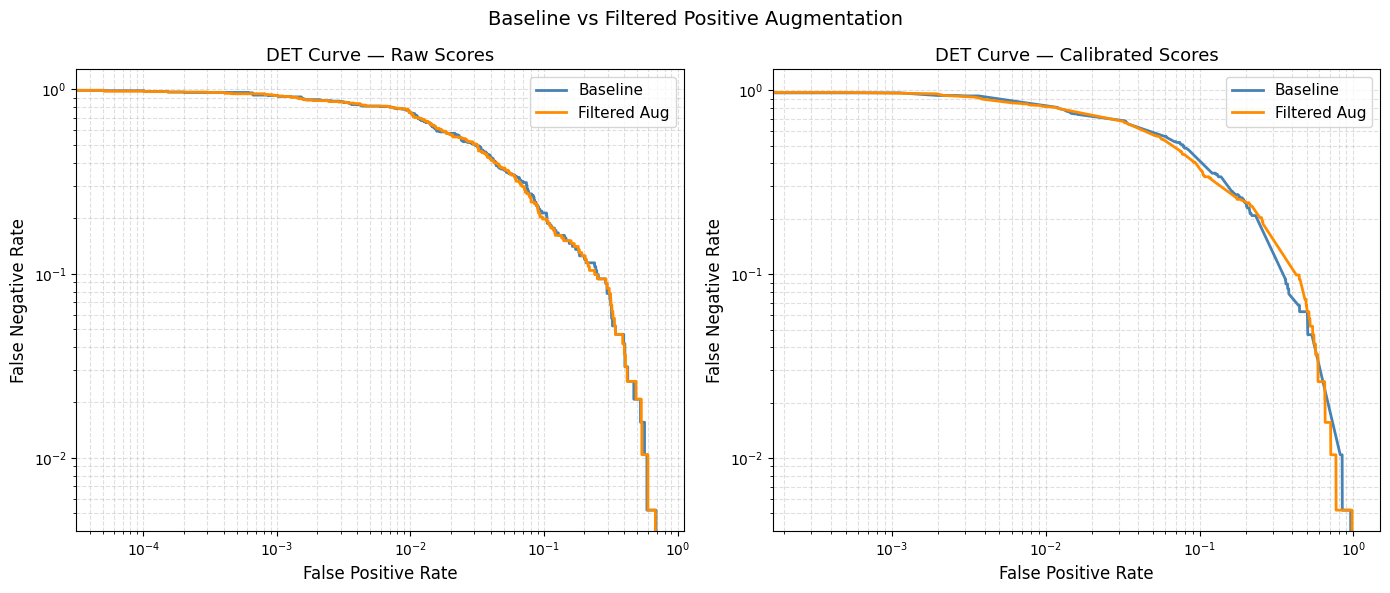

Saved.


In [25]:
fpr_filt, fnr_filt, _ = det_curve(y_test, y_scores_filt)
fpr_filt_cal, fnr_filt_cal, _ = det_curve(y_test, y_scores_filt_cal)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Raw
ax1.plot(fpr_base, fnr_base, color='steelblue', linewidth=2, label='Baseline')
ax1.plot(fpr_filt, fnr_filt, color='darkorange', linewidth=2, label='Filtered Aug')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('False Negative Rate', fontsize=12)
ax1.set_title('DET Curve — Raw Scores', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, which='both', linestyle='--', alpha=0.4)

# Calibrated
ax2.plot(fpr_base_cal, fnr_base_cal, color='steelblue', linewidth=2, label='Baseline')
ax2.plot(fpr_filt_cal, fnr_filt_cal, color='darkorange', linewidth=2, label='Filtered Aug')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('False Negative Rate', fontsize=12)
ax2.set_title('DET Curve — Calibrated Scores', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, which='both', linestyle='--', alpha=0.4)

plt.suptitle('Baseline vs Filtered Positive Augmentation', fontsize=14)
plt.tight_layout()
plt.savefig("data/results/filtered_positive_det.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

## Full Comparison Table — All Positive Augmentation Conditions
Summary of raw and calibrated metrics across baseline, unfiltered, and filtered
augmentation. Calibrated metrics are the primary reference for comparison.
Threshold column shows optimal calibrated threshold for each condition.

In [26]:
# Load all saved metrics
with open("data/results/baseline_metrics.json") as f:
    m_base = json.load(f)["baseline"]
with open("data/results/unfiltered_aug_metrics.json") as f:
    m_aug = json.load(f)["unfiltered_augmented"]
with open("data/results/filtered_aug_metrics.json") as f:
    m_filt = json.load(f)["filtered_augmented"]

print(f"{'Condition':<20} {'P(raw)':>8} {'R(raw)':>8} {'F1(raw)':>8} "
      f"{'P(cal)':>8} {'R(cal)':>8} {'F1(cal)':>8} {'τ':>6}")
print("-" * 82)

conditions = [
    ("Baseline",        m_base),
    ("Unfiltered Aug",  m_aug),
    ("Filtered Aug",    m_filt),
]

for name, m in conditions:
    print(f"{name:<20} "
          f"{m['raw']['precision']:>8.3f} "
          f"{m['raw']['recall']:>8.3f} "
          f"{m['raw']['f1']:>8.3f} "
          f"{m['calibrated']['precision']:>8.3f} "
          f"{m['calibrated']['recall']:>8.3f} "
          f"{m['calibrated']['f1']:>8.3f} "
          f"{m['calibrated']['threshold']:>6.2f}")

Condition              P(raw)   R(raw)  F1(raw)   P(cal)   R(cal)  F1(cal)      τ
----------------------------------------------------------------------------------
Baseline                0.059    0.839    0.110    0.136    0.260    0.179   0.07
Unfiltered Aug          0.068    0.729    0.124    0.120    0.219    0.155   0.11
Filtered Aug            0.065    0.823    0.121    0.173    0.167    0.170   0.13


In [27]:
import csv

rows = []
for name, m in conditions:
    rows.append({
        "condition": name,
        "precision_raw": m['raw']['precision'],
        "recall_raw": m['raw']['recall'],
        "f1_raw": m['raw']['f1'],
        "precision_cal": m['calibrated']['precision'],
        "recall_cal": m['calibrated']['recall'],
        "f1_cal": m['calibrated']['f1'],
        "threshold_cal": m['calibrated']['threshold'],
    })

comparison_df = pd.DataFrame(rows)
comparison_df.to_csv("data/results/positive_augmentation_comparison.csv", index=False)
print(comparison_df.to_string(index=False))
print("\nSaved to data/results/positive_augmentation_comparison.csv")

     condition  precision_raw  recall_raw  f1_raw  precision_cal  recall_cal  f1_cal  threshold_cal
      Baseline          0.059       0.839   0.110          0.136       0.260   0.179           0.07
Unfiltered Aug          0.068       0.729   0.124          0.120       0.219   0.155           0.11
  Filtered Aug          0.065       0.823   0.121          0.173       0.167   0.170           0.13

Saved to data/results/positive_augmentation_comparison.csv


## UMAP — Filtered Synthetic Positives in Embedding Space
Shows where the 173 filtered survivors land relative to real positives and negatives.
Completes the geometric story of the positive augmentation chapter — are filtered
synthetics landing closer to the real positive manifold than the unfiltered set?

In [28]:
# Stack real data + filtered synthetics for UMAP
X_umap_filtered = np.vstack([
    X_train[pos_idx],        # real positives
    X_train[neg_sample_idx], # sampled negatives
    X_syn_filtered           # filtered synthetic positives
])

labels_filtered = np.array(
    ['Real Positive'] * len(pos_idx) +
    ['Real Negative'] * len(neg_sample_idx) +
    ['Filtered Synthetic'] * len(X_syn_filtered)
)

print(f"Real positives: {len(pos_idx)}")
print(f"Real negatives (sampled): {len(neg_sample_idx)}")
print(f"Filtered synthetics: {len(X_syn_filtered)}")
print("Fitting UMAP...")

reducer_filtered = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
embedding_filtered = reducer_filtered.fit_transform(X_umap_filtered)
print("Done.")

Real positives: 674
Real negatives (sampled): 2000
Filtered synthetics: 173
Fitting UMAP...


c:\Users\vkamat01\hedging-txtclf-experiments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done.


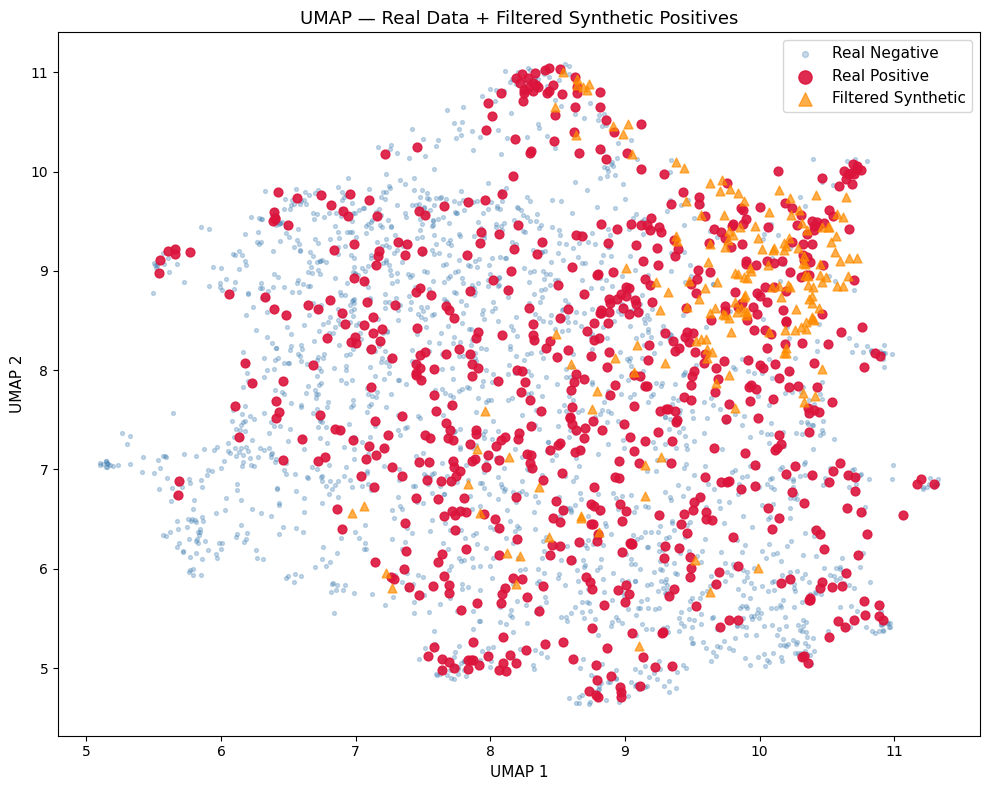

Saved.


In [30]:
color_map = {
    'Real Negative': 'steelblue',
    'Real Positive': 'crimson',
    'Filtered Synthetic': 'darkorange'
}

marker_map = {
    'Real Negative': 'o',
    'Real Positive': 'o',
    'Filtered Synthetic': '^'
}

size_map = {
    'Real Negative': 8,
    'Real Positive': 40,
    'Filtered Synthetic': 40
}

alpha_map = {
    'Real Negative': 0.3,
    'Real Positive': 0.9,
    'Filtered Synthetic': 0.7
}

fig, ax = plt.subplots(figsize=(10, 8))

for label in ['Real Negative', 'Real Positive', 'Filtered Synthetic']:
    mask = labels_filtered == label
    ax.scatter(
        embedding_filtered[mask, 0],
        embedding_filtered[mask, 1],
        c=color_map[label],
        marker=marker_map[label],
        s=size_map[label],
        alpha=alpha_map[label],
        label=label
    )

ax.set_title('UMAP — Real Data + Filtered Synthetic Positives', fontsize=13)
ax.legend(fontsize=11, markerscale=1.5)
ax.set_xlabel('UMAP 1', fontsize=11)
ax.set_ylabel('UMAP 2', fontsize=11)
plt.tight_layout()
plt.savefig("data/results/umap_filtered_synthetics.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")